# LangChain: Models, Prompts and Output Parsers

### Outline
- Direct API calls to OpenAI
- API calls through LangChain:
    - Prompts
    - Models

In [1]:
### Install langchain 
#!pip install --upgrade langchain-openai

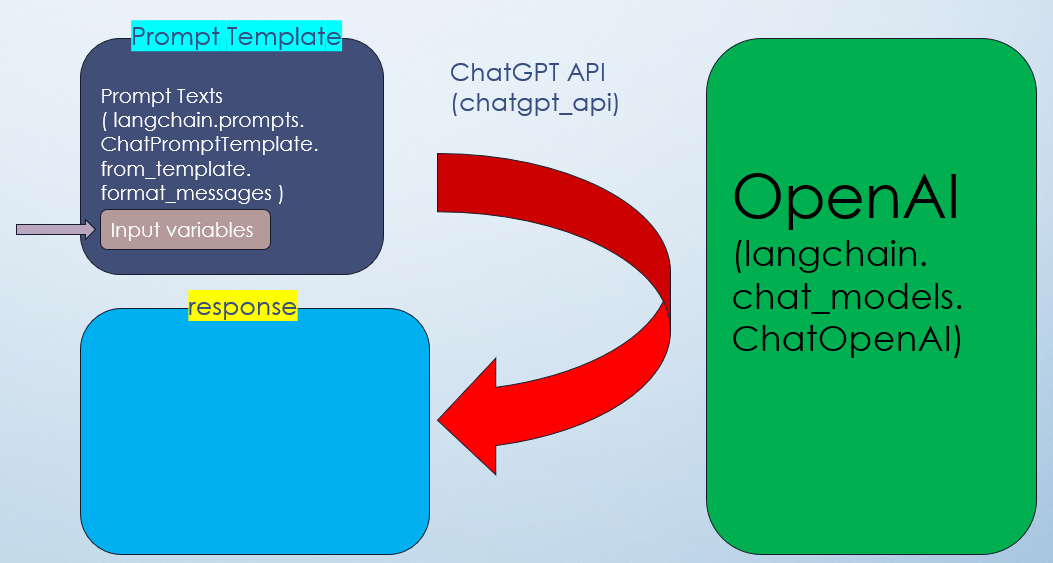

### Model - ChatGPT

In [2]:
## import langchina ChatGPT
from langchain_openai import ChatOpenAI

In [3]:
## import os and dotenv for environmental varialbes
import os
from dotenv import load_dotenv, dotenv_values

load_dotenv() ## import environment variable instance

True

In [4]:
# To control the randomness and creativity of the generated
# text by an LLM, use temperature = 0.0
chat = ChatOpenAI(temperature=0.0, 
                  openai_api_key=os.getenv("chatgpt_api"))
chat

ChatOpenAI(profile={'max_input_tokens': 16385, 'max_output_tokens': 4096, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': False, 'structured_output': False, 'image_url_inputs': False, 'pdf_inputs': False, 'pdf_tool_message': False, 'image_tool_message': False, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000021703191940>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000217036EDA60>, root_client=<openai.OpenAI object at 0x00000217006F4650>, root_async_client=<openai.AsyncOpenAI object at 0x0000021703279AF0>, temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

### Prompt template

In [6]:
## import lagnchain prompt template 
from langchain_core.prompts import ChatPromptTemplate

In [7]:
template_string = """Convert below codes \
codes : {codes} \
into {new_language} computer language.
"""

In [8]:
## Create Prompt Template
prompt_template = ChatPromptTemplate.from_template(template_string)

prompt_template.messages[0].prompt ## review the prompt - input_variables & template

PromptTemplate(input_variables=['codes', 'new_language'], input_types={}, partial_variables={}, template='Convert below codes codes : {codes} into {new_language} computer language.\n')

#### Crate input variables

In [9]:
codes = """
This is SAS codes \
data dm; \
   merge demo  rand; \
   by usubjid; \
run;
"""

In [10]:
new_language = """ python
"""

In [11]:
new_language = """ R
"""

In [12]:
## Insert input variables into Prompt Template
customer_messages = prompt_template.format_messages(
                    codes = codes,
                    new_language = new_language)

In [13]:
print(customer_messages)

[HumanMessage(content='Convert below codes codes : \nThis is SAS codes data dm;    merge demo  rand;    by usubjid; run;\n into  R\n computer language.\n', additional_kwargs={}, response_metadata={})]


In [14]:
# Prompt expected by the user 
print(customer_messages[0])

content='Convert below codes codes : \nThis is SAS codes data dm;    merge demo  rand;    by usubjid; run;\n into  R\n computer language.\n' additional_kwargs={} response_metadata={}


### Run LLM model using prompt

In [15]:
## Run LLM 
customer_response = chat.invoke(customer_messages)


In [16]:
print(customer_response.content)

dm <- merge(demo, rand, by = "usubjid")
